In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

ds_train, ds_test = tfds.load('svhn_cropped', split=['train', 'test'], as_supervised=True)

def tfds_to_numpy(dataset):
  X = []
  y = []
  for image, label in tfds.as_numpy(dataset):
    X.append(image)
    y.append(label)
  return np.array(X), np.array(y)

X_train, y_train = tfds_to_numpy(ds_train)
X_test, y_test = tfds_to_numpy(ds_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape:", y_test.shape)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.M85AOT_3.1.0/svhn_cropped-train.tfrecord*...:   0%…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.M85AOT_3.1.0/svhn_cropped-test.tfrecord*...:   0%|…

Generating extra examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.M85AOT_3.1.0/svhn_cropped-extra.tfrecord*...:   0%…

Dataset svhn_cropped downloaded and prepared to /root/tensorflow_datasets/svhn_cropped/3.1.0. Subsequent calls will reuse this data.
X_train shape: (73257, 32, 32, 3)
y_train shape: (73257,)
X_test shape:  (26032, 32, 32, 3)
y_test shape: (26032,)


SVHN is more challenging because MNIST digits are placed on a clear background, whereas SVHN digits appear in real world streets, meaning that the background could be noisy or complex. There are also different lighting conditions and multiple digits per image for SVHN. SVHN is also RGB while MNIST is grayscale

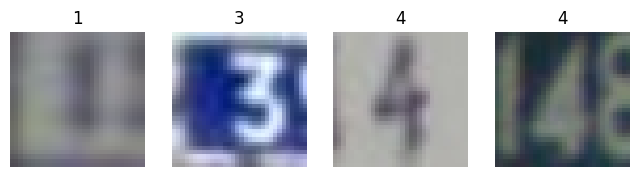

In [ ]:
import matplotlib.pyplot as plt

indices = np.random.choice(len(X_train), 4, replace=False)
plt.figure(figsize=(8, 3))
for i, idx in enumerate(indices):
  plt.subplot(1, 4, i+1)
  plt.imshow(X_train[idx])
  plt.title(y_train[idx])
  plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical

#Normalize images to [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

#One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

The images are in busy, real-world backgrounds. A major difficulty would be the SVHN model distinguishing the digit from the background.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 224

base_model = ResNet50(
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = layers.Lambda(preprocess_input)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train_cat,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 191s 190ms/step - accuracy: 0.1773 - loss: 2.2754 - val_accuracy: 0.1907 - val_loss: 2.2345
Epoch 2/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 159s 173ms/step - accuracy: 0.1896 - loss: 2.2395 - val_accuracy: 0.1907 - val_loss: 2.2353
Epoch 3/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 158s 173ms/step - accuracy: 0.1898 - loss: 2.2393 - val_accuracy: 0.1907 - val_loss: 2.2346
Epoch 4/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 158s 173ms/step - accuracy: 0.1906 - loss: 2.2371 - val_accuracy: 0.1907 - val_loss: 2.2346
Epoch 5/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 158s 173ms/step - accuracy: 0.1886 - loss: 2.2384 - val_accuracy: 0.1907 - val_loss: 2.2345
Epoch 6/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 158s 173ms/step - accuracy: 0.1914 - loss: 2.2361 - val_accuracy: 0.1907 - val_loss: 2.2344
Epoch 7/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 158s 173ms/step - accuracy: 0.1845 - loss: 2.2422 - val_accuracy: 0.1907 - val_loss: 2.2345
Epoch 8/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 158s 173ms/step - accuracy: 0.1895 -

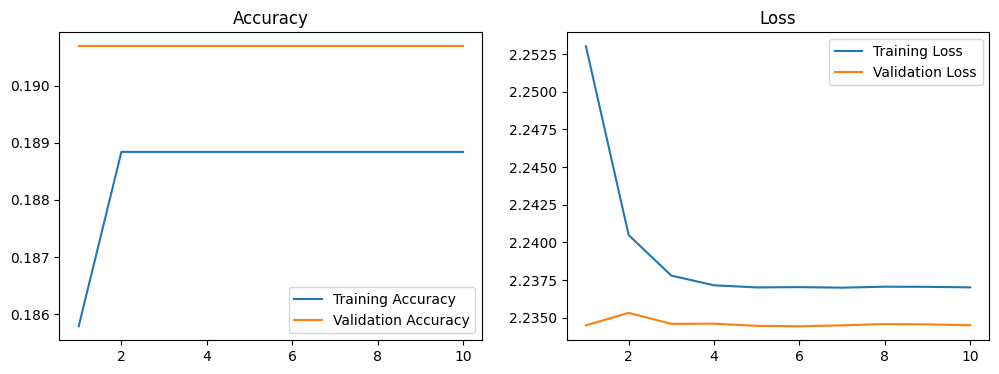

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Loss')

    plt.show()

plot_history(history)


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

814/814 ━━━━━━━━━━━━━━━━━━━━ 66s 81ms/step - accuracy: 0.2001 - loss: 2.2216
Test accuracy: 0.19587430357933044


I trained the model multiple times, changing the epochs, batchsize, learning rate and even added dropout but i couldn't get the accuracy to increase from 19%. The model underfits, showing that the model can't handle this set of data. Another change is decreasing the dropout to 0.5, allows the classifier to learn.

Dataset complexity alone does not determine transfer learning success feature similarity between datasets is more important. While CIFAR-100 is more complex in terms of class diversity, transfer learning performed better on it than SVHN because its visual features align more closely with ImageNet. Applying pretrained models to SVHN required adjustments, including fine-tuning and careful preprocessing, this shows that dataset compatability is important in transfer learning.